# 4) Joint inversion of field data using cross gradients

In this example, we jointly invert ERT and SRT data using cross gradients.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pygimli.physics.traveltime as tt


data_ERT = pg.load("../data/AV_DD_2.dat")
data_SRT = pg.load("../data/SRT_P2_coords.sgt")


In [2]:
sensERT = np.array(data_ERT.sensorPositions())
sensSRT = np.array(data_SRT.sensorPositions())
sensERT[:,1] = sensERT[:,2]
sensERT[:,2] = 0.0
sensBoth = np.vstack([sensERT, sensSRT])
ind = np.argsort(sensBoth[:, 0])

In [3]:
sensBoth_sorted = sensBoth[ind]
ind = np.unique(sensBoth_sorted[:, 0], return_index=True)

In [4]:
sensBoth = sensBoth_sorted[ind[1]]

In [5]:
data_ERT["k"] = ert.createGeometricFactors(data_ERT, numerical=True)
data_ERT["rhoa"] = data_ERT["k"] * data_ERT["r"]

data_ERT["err"] = ert.estimateError(data_ERT, relativeError=0.0175, absoluteError=0.004)

mgr_ERT = ert.ERTManager(data_ERT)
plc = mt.createParaMeshPLC(sensBoth,  paraDepth=15, paraMaxCellSize=2.5)

mesh = mt.createMesh(plc)
mgr_ERT.setMesh(mesh)
print(mesh)

20/09/26 - 07:59:08 - pyGIMLi - INFO - Cache c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (3.5s x 2): C:\Users\alexa\AppData\Roaming\pygimli\Cache\8825866756095047884


20/09/26 - 07:59:08 - pyGIMLi - INFO - Found 2 regions.
20/09/26 - 07:59:08 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Mesh: Nodes: 1567 Cells: 2816 Boundaries: 4382


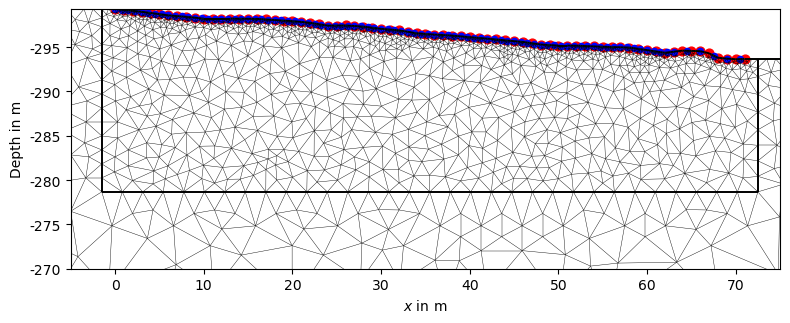

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
pg.show(mesh, ax=ax)
ax.set_xlim(-5, 75)
ax.set_ylim(270,)
ax.scatter(data_ERT.sensorPositions()[:, 0], data_ERT.sensorPositions()[:, 2], c="r", s=40, label="Electrodes")
ax.scatter(data_SRT.sensorPositions()[:, 0], data_SRT.sensorPositions()[:, 1], c="b", s=20, label="Geophones")

In [7]:
invArgs = dict(lam = 45, robustData=False, blockyModel=False, verbose=True)

inv = mgr_ERT.invert(**invArgs)

20/09/26 - 07:59:08 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/09/26 - 07:59:09 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
20/09/26 - 07:59:09 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 5949 Cells: 11264 Boundaries: 8764
20/09/26 - 07:59:09 - pyGIMLi - INFO - Use median(data values)=145.18666371512103
20/09/26 - 07:59:09 - pyGIMLi - INFO - Created startmodel from forward operator:2347, min/max=145.186664/145.186664
20/09/26 - 07:59:09 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000002626847B420>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 20.48/759
min/max (error): 1.75%/1.77%
min/max (start model): 145/145
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  445.38
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  105.30 (dPhi = 76.05%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    8.24 (dPhi = 90.36%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    3.21 (dPhi = 51.01%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    3.04 (dPhi = 5.04%) lam: 45.0
--------------------------------------------------

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x2626d347e50>)

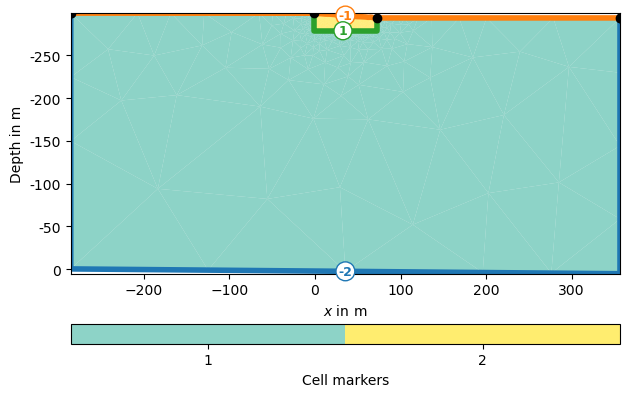

In [8]:
pg.show(mgr_ERT.mesh, markers=True)

In [9]:
meshSRT = mgr_ERT.paraDomain
for c in meshSRT.cells():
    c.setMarker(2)
mgr_SRT = tt.TravelTimeManager(data_SRT)
inv_SRT = mgr_SRT.invert(mesh=meshSRT,maxIter=20, verbose=True)

20/09/26 - 08:00:13 - pyGIMLi - INFO - Found 1 regions.
20/09/26 - 08:00:13 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/09/26 - 08:00:13 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
20/09/26 - 08:00:14 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
20/09/26 - 08:00:14 - pyGIMLi - INFO - Created startmodel from forward operator:2347, min/max=0.000200/0.002000
20/09/26 - 08:00:14 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x00000262773E0A90>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.0013/0.06
min/max (error): 3%/76.86%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  369.16
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  229.50 (dPhi = 37.74%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   27.26 (dPhi = 87.70%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.14 (dPhi = 91.06%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.01 (dPhi = 9.34%) lam: 20.0
-----------------------------------------------------------------

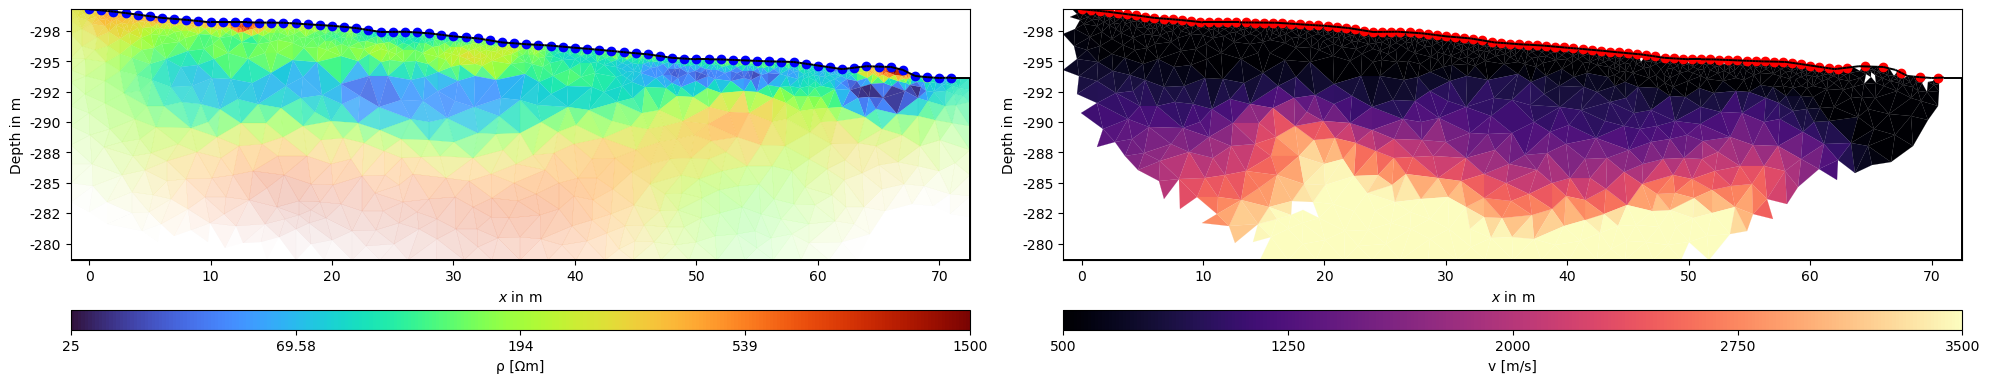

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mgr_ERT.paraDomain, data=inv, ax=ax1, label='ρ [Ωm]', cMap='turbo', cMin=25, cMax=1500,showMesh=False, logScale=True, coverage=mgr_ERT.coverage())
pg.show(mgr_SRT.paraDomain, data=inv_SRT, ax=ax2, label='v [m/s]', cMap='magma', cMin=500, cMax=3500, showMesh=False, coverage=mgr_SRT.standardizedCoverage())
ax1.scatter(data_ERT.sensors()[:,0], data_ERT.sensors()[:,2], color='blue')
ax2.scatter(data_SRT.sensors()[:,0], data_SRT.sensors()[:,1], color='red')

In [11]:
import jointtools.JItools as JI

crossfop = JI.crossGradient(
    fopList=[mgr_ERT.fop, mgr_SRT.fop], 
    dataList=[data_ERT['rhoa'], data_SRT['t']], 
    errorList=[data_ERT['err'], data_SRT['err']/data_SRT['t']], 
    meshList=[mesh, meshSRT],
    alpha = 0,
    smooth = False
    )

20/09/26 - 08:00:34 - pyGIMLi - INFO - Found 2 regions.
20/09/26 - 08:00:34 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/09/26 - 08:00:34 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/09/26 - 08:00:34 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
20/09/26 - 08:00:34 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 5949 Cells: 11264 Boundaries: 8764
20/09/26 - 08:00:34 - pyGIMLi - INFO - Found 1 regions.
20/09/26 - 08:00:34 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/09/26 - 08:00:34 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


In [12]:
dataVec = np.concatenate((np.array(data_ERT['rhoa']), np.array(data_SRT['t'])))
errorVec = np.concatenate((np.array(data_ERT['err']), np.array(data_SRT['err']/data_SRT['t'])))

In [13]:
startmodel_ERT = mgr_ERT.fop.createStartModel(data_ERT['rhoa'])
startmodel_SRT = mgr_SRT.fop.createStartModel(data_SRT['t'])

startmodel = np.concatenate([startmodel_ERT,startmodel_SRT])

#crossfop.createJacobian(startmodel)
#pg.show(crossfop.constraints())

20/09/26 - 08:00:34 - pyGIMLi - INFO - Use median(data values)=145.18666371512103
20/09/26 - 08:00:34 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


In [ ]:
from pygimli.frameworks.inversion import GaussNewtonInversion as GN
inv = GN(fop=crossfop)
modelGN = inv.run(dataVals=dataVec, errorVals=errorVec, startModel=startmodel, verbose=True)
print(r'Final $\chi^2$ = ', inv.chi2())

20/09/26 - 08:00:34 - pyGIMLi - INFO - Starting inversion.


fop: <jointtools.JItools.crossGradient object at 0x00000262701BD5D0>
Data transformation: Identity transform
Model transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 0.0013/759
min/max (error): 1.75%/76.86%
min/max (start model): 2.0e-04/145
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  561.26
--------------------------------------------------------------------------------
inv.iter 1 ... dM:  4694 [-0.3399643911018158,...,0.08304564308300129]
tau:  0.15322569337958122
chi² =  382.08 (dPhi = nan%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... dM:  4694 [-0.2564733530043503,...,-0.03847491217350632]
tau:  0.6535000000000001
chi² =   55.54 (dPhi = 85.10%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... dM:  4694 [-0.05439612345233137,...,0.1334168595964789]
tau:  0.802
chi² = 

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x211e9e3f390>)

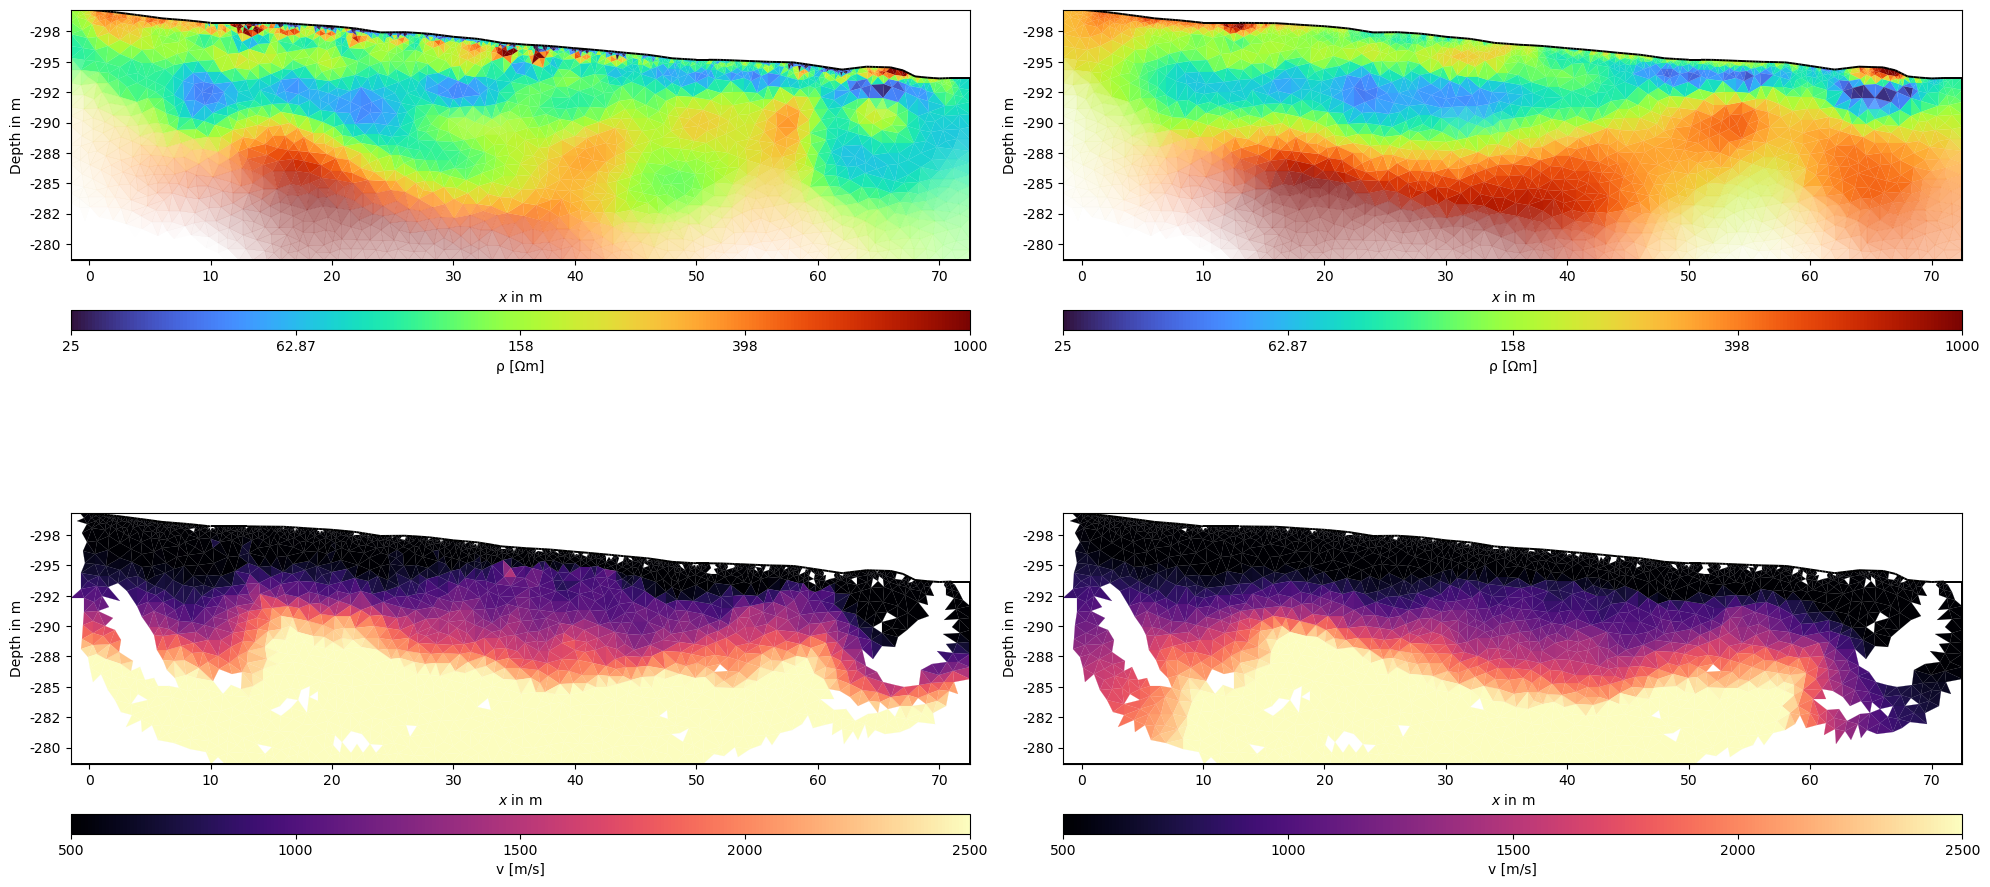

In [ ]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(20, 14))
pg.show(meshSRT, data=np.split(modelGN,2)[0], ax=ax1, cMap='turbo', cMin=25, cMax=1000, label='ρ [Ωm]', colorBar=True,  logScale=True, coverage=mgr_ERT.coverage())
pg.show(meshSRT, data=mgr_ERT.model, ax=ax2, cMap='turbo', cMin=25, cMax=1000, label='ρ [Ωm]', colorBar=True,  logScale=True, coverage=mgr_ERT.coverage())

pg.show(meshSRT, data=np.split(1/modelGN,2)[1], ax=ax3, cMap='magma', cMin=500, cMax=2500, label='v [m/s]', colorBar=True,  logScale=False, coverage=mgr_SRT.standardizedCoverage())
pg.show(meshSRT, data=mgr_SRT.model, ax=ax4, cMap='magma', cMin=500, cMax=2500, label='v [m/s]', colorBar=True,  logScale=False, coverage = mgr_SRT.standardizedCoverage())

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x211ea15fdd0>)

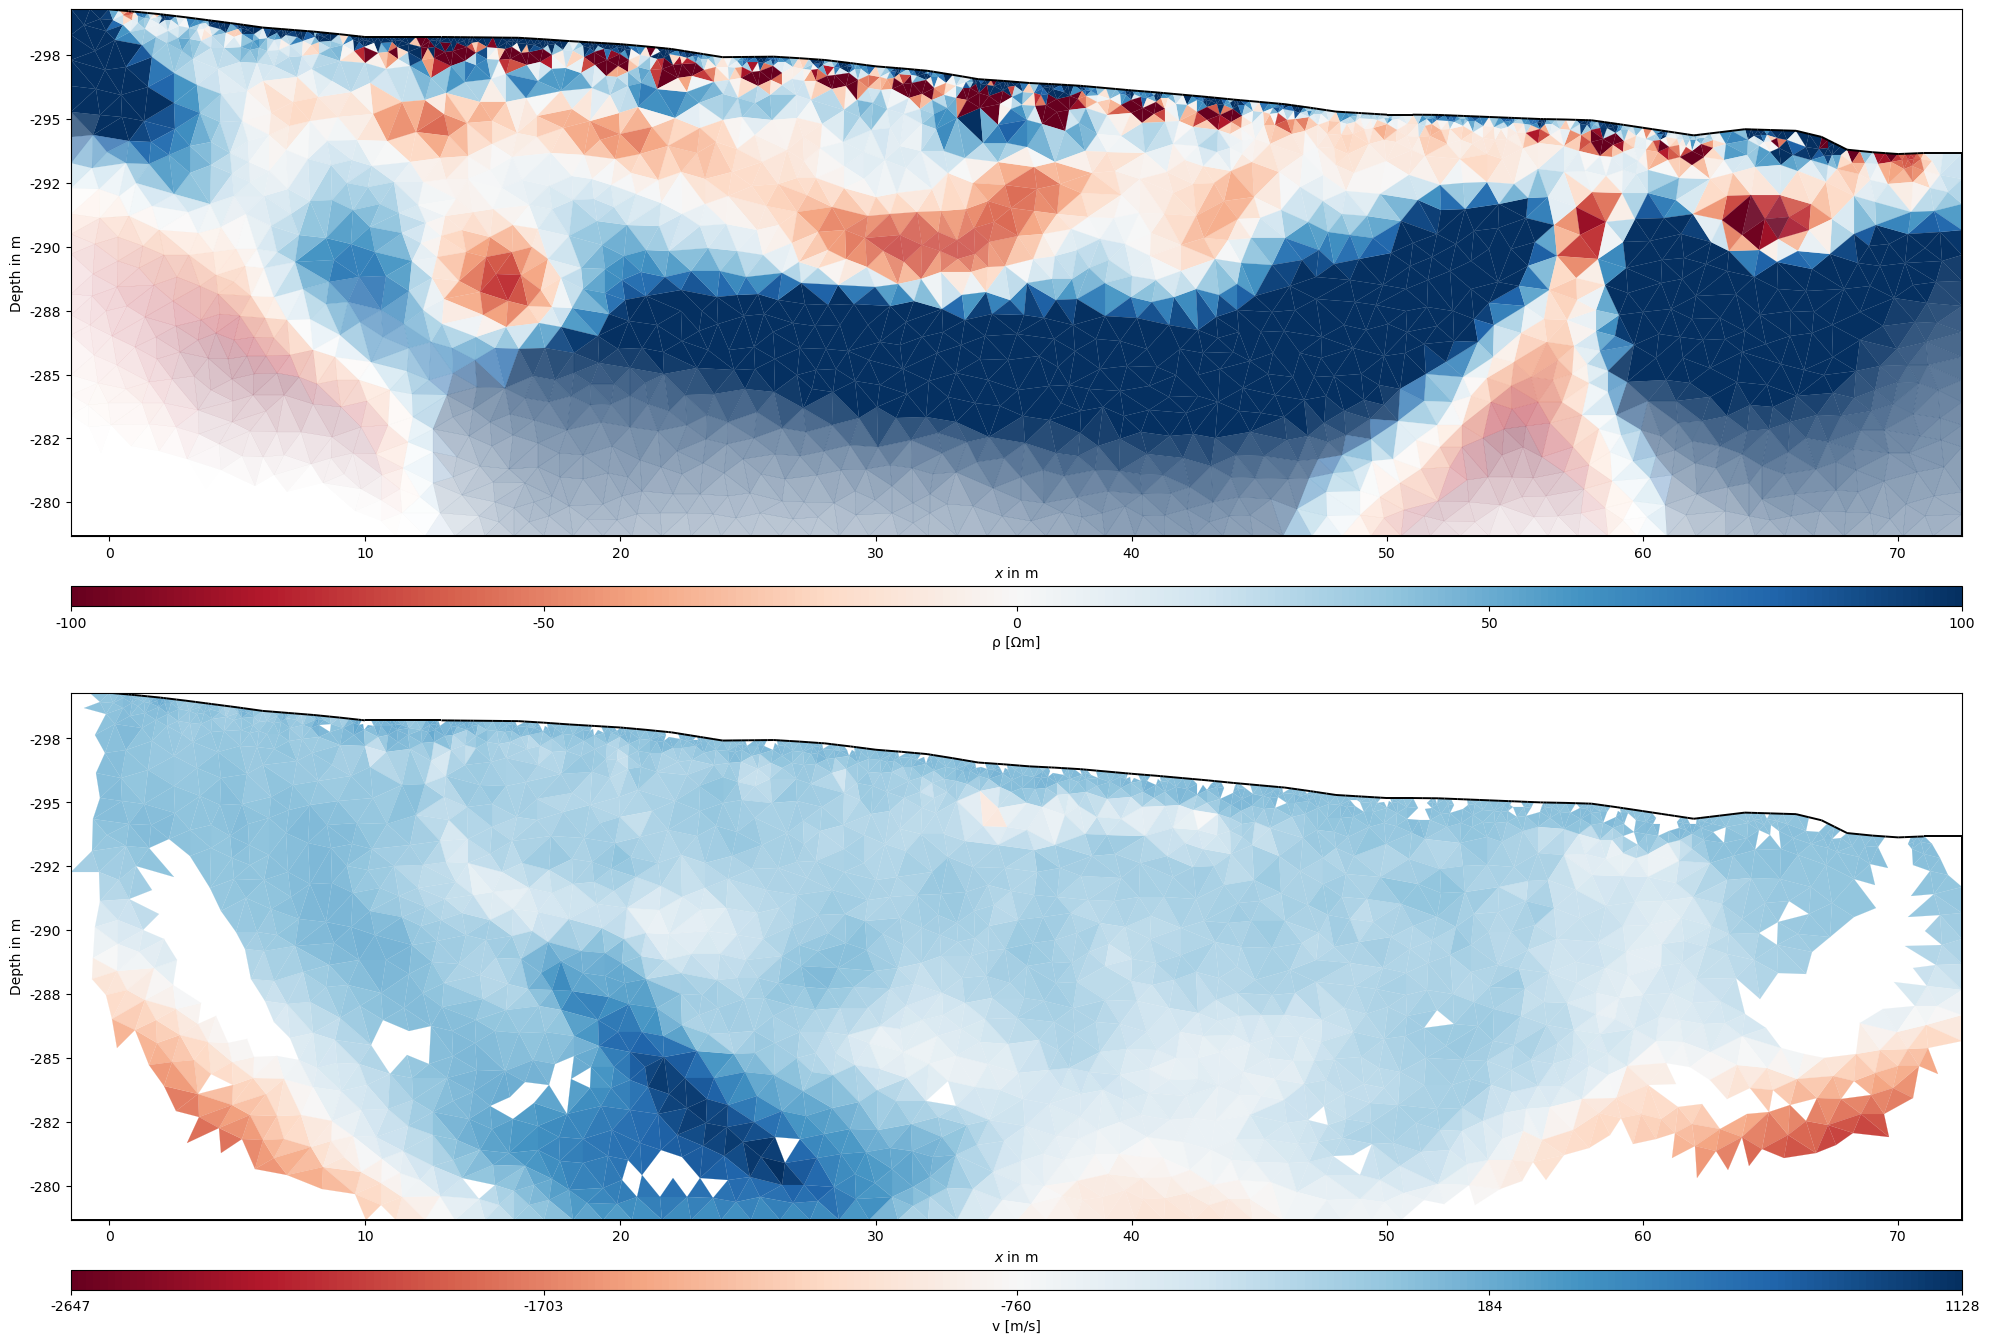

In [ ]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(20, 14))

pg.show(meshSRT, data=(mgr_ERT.model-np.split(modelGN,2)[0]), ax=ax1, cMap='RdBu', label='ρ [Ωm]', colorBar=True, logScale=False, coverage=mgr_ERT.coverage(), cMin=-100, cMax=100)

pg.show(meshSRT, data=(mgr_SRT.model-np.split(1/modelGN,2)[1]), ax=ax2, cMap='RdBu', label='v [m/s]', colorBar=True,  logScale=False, coverage=mgr_SRT.standardizedCoverage())
